### This is code for analysis on AQI of India for the month of October

In [1]:
!pip install geopandas


[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pyshp


[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import shapefile as shp
from shapely.geometry import Point
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings("ignore")

import requests # library to handle requests
from bs4 import BeautifulSoup # library to parse HTML documents

## Scraping Population Table from wikipedia

In [99]:
# get the response in the form of html
wikiurl="https://en.wikipedia.org/wiki/List_of_states_and_union_territories_of_India_by_population"
table_class="wikitable sortable jquery-tablesorter"
response=requests.get(wikiurl)
print(response.status_code)

200


In [103]:
# parse data from the html into a beautifulsoup object
soup = BeautifulSoup(response.text, 'html.parser')
indiatable=soup.find('table',{'class':"wikitable"})

In [104]:
population=pd.read_html(str(indiatable),header=None,)
# convert list to dataframe
population=pd.DataFrame(population[0])
population.to_csv("population.csv")

In [106]:
population = pd.read_csv("populationn.csv",index_col="Unnamed: 0")
population

,Rank,State or Union Territory,Population,National Share (%),Decadal growth(2001–2012),Rural population,Percent rural,Urban population,Percent urban,Population Density[a],Sex ratio
0,1 (S1),Uttar Pradesh,199812341,NaN,20.20%,155317278,NaN,44495063,NaN,"828/km2 (2,140/sq mi)",912
1,2 (S2),Maharashtra,112374333,NaN,16%,61556074,NaN,50818259,NaN,365/km2 (950/sq mi),929
2,3 (S3),Bihar,104099452,NaN,25.40%,92341436,NaN,11758016,NaN,"1,102/km2 (2,850/sq mi)",918
3,4 (S4),West Bengal,91276115,NaN,13.80%,62183113,NaN,29093002,NaN,"1,029/km2 (2,670/sq mi)",953
4,5 (S5),Madhya Pradesh,72626809,NaN,16.30%,52557404,NaN,20069405,NaN,236/km2 (610/sq mi),931
5,6 (S6),Tamil Nadu,72147030,NaN,15.60%,37229590,NaN,34917440,NaN,"555/km2 (1,440/sq mi)",996
6,7 (S7),Rajasthan,68548437,NaN,21.30%,51500352,NaN,17048085,NaN,201/km2 (520/sq mi),928
7,8 (S8),Karnataka,61095297,NaN,15.60%,30069335,NaN,31025962,NaN,319/km2 (830/sq mi),979
8,9 (S9),Gujarat,60439692,NaN,19.30%,34694609,NaN,25745083,NaN,308/km2 (800/sq mi),919
9,10 (S10),Andhra Pradesh,"49,577,103[b]",NaN,11.00%,34966693,NaN,14610410,NaN,303/km2 (780/sq mi),993


In [108]:
population= population[["State or Union Territory","Population","Population Density[a]"]]
population.Population = population.Population.astype('str').str.extractall('(\d+)').unstack().fillna('').sum(axis=1).astype(int)

In [129]:
density = population["Population Density[a]"].str.split("/km2")
density = [i[0] for i in density]
population["density"]=density
population["density"] = population["density"].str.replace(",","")
population["density"]=population["density"].astype("float32")

In [130]:
population

,State or Union Territory,Population,Population Density[a],density
0,Uttar Pradesh,199812341,"828/km2 (2,140/sq mi)",828.0
1,Maharashtra,112374333,365/km2 (950/sq mi),365.0
2,Bihar,104099452,"1,102/km2 (2,850/sq mi)",1102.0
3,West Bengal,91276115,"1,029/km2 (2,670/sq mi)",1029.0
4,Madhya Pradesh,72626809,236/km2 (610/sq mi),236.0
5,Tamil Nadu,72147030,"555/km2 (1,440/sq mi)",555.0
6,Rajasthan,68548437,201/km2 (520/sq mi),201.0
7,Karnataka,61095297,319/km2 (830/sq mi),319.0
8,Gujarat,60439692,308/km2 (800/sq mi),308.0
9,Andhra Pradesh,49577103,303/km2 (780/sq mi),303.0


## Loading the data

In [131]:
df_start = pd.read_excel("Downloads/AQI_all_station2022_10_02T16_00_00Z.xlsx")
df_end = pd.read_excel("Downloads/AQI_all_station2022_10_31T16_00_00Z.xlsx")

## Filling missing values

In [132]:
def fill_nulls(x:list):
    b = []
    for i in x:
        if type(i) == str:
            a = i
            b.append(a)
        elif type(i) == float:
            b.append(a)
    return b

In [133]:
## for start date
x = df_start['State']
x = list(x)
df_start["State"] = fill_nulls(x)

x = df_start['Station Name']
x = list(x)
df_start["Station Name"] = fill_nulls(x)

x = df_start['City']
x = list(x)
df_start["City"] = fill_nulls(x)

## for end date
x = df_end['State']
x = list(x)
df_end["State"] = fill_nulls(x)

x = df_end['Station Name']
x = list(x)
df_end["Station Name"] = fill_nulls(x)

x = df_end['City']
x = list(x)
df_end["City"] = fill_nulls(x)

## Cleaning and preprocessing the data

In [134]:
## Getting rid of all the data that doesn't have AQI available
df_start = df_start[df_start['Current AQI value']!="Insufficient data available in last 24 hours."]
df_end = df_end[df_end['Current AQI value']!="Insufficient data available in last 24 hours."]

In [135]:
## changing datatype of AQI column
df_end['Current AQI value'] = df_end['Current AQI value'].astype("int64")
df_start['Current AQI value'] = df_start['Current AQI value'].astype("int64")

In [136]:
df_start = df_start.drop(["Station Name","S.No."],axis=1)
df_end = df_end.drop(["Station Name","S.No."],axis=1)

In [137]:
## Grouping the data to make it more compact
df_start = df_start.groupby(["State","City"]).mean("Current AQI value").reset_index()
df_end = df_end.groupby(["State","City"]).mean("Current AQI value").reset_index()

In [138]:
df_start = df_start.replace("Delhi", "NCT of Delhi")
df_end = df_end.replace("Delhi", "NCT of Delhi")

In [139]:
df_start = pd.merge(df_start,population,how = "left",left_on = "State",right_on = 'State or Union Territory')
df_end = pd.merge(df_end,population,how = "left",left_on = "State",right_on = 'State or Union Territory')

df_start.dropna(inplace=True)
df_end.dropna(inplace =True)

## Analyzing certain details

In [140]:
s,e = df_start['Current AQI value'].mean(),df_end['Current AQI value'].mean()
print(f"There has been an increase of {((e-s)/s)*100}%")

There has been an increase of 5.25893648509263%


In [141]:
bad_cities = df_start.groupby("City")["Current AQI value"].max().reset_index()\
                .sort_values("Current AQI value",ascending=False).reset_index().iloc[:15]
good_cities = df_start.groupby("City")["Current AQI value"].max().reset_index()\
                .sort_values("Current AQI value",ascending=False).reset_index().iloc[-15:]

## Visualizing the data

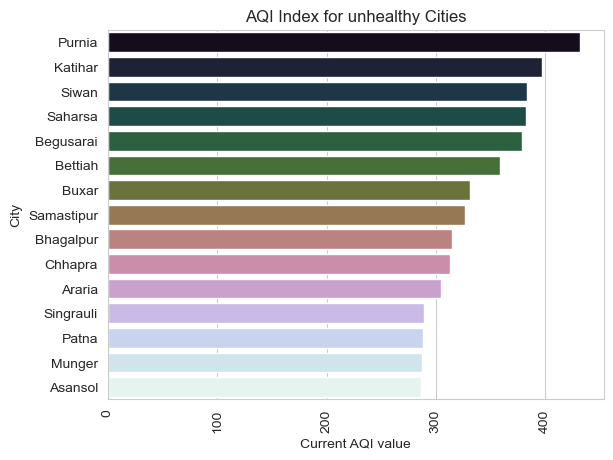

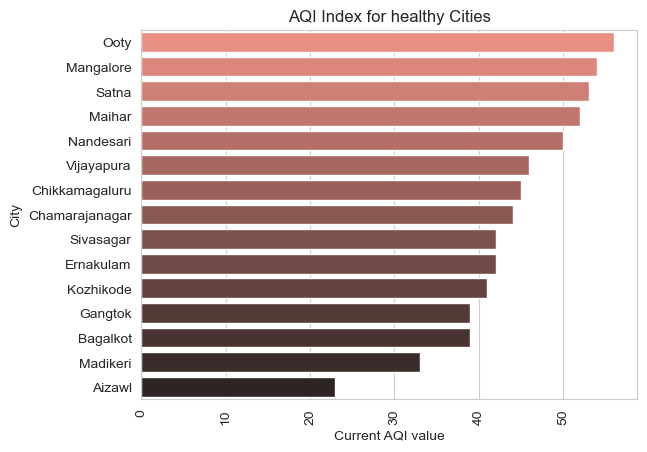

In [142]:
for num,i in enumerate([bad_cities,good_cities]):
    title = ["unhealthy Cities","healthy Cities"]
    palette = ["cubehelix","dark:salmon_r"]
    ax = sns.barplot(data = i,y = "City",x = "Current AQI value",palette=palette[num])
    plt.title(f"AQI Index for {title[num]}")
    plt.xticks(rotation=90)
    plt.show()

In [143]:
state_srt = df_start.groupby("State").mean("Current AQI value").sort_values("Current AQI value",ascending =False).reset_index()
state_end = df_end.groupby("State").mean("Current AQI value").sort_values("Current AQI value",ascending =False).reset_index()

In [144]:
state_srt = state_srt.replace("Delhi", "NCT of Delhi")
state_end = state_end.replace("Delhi", "NCT of Delhi")

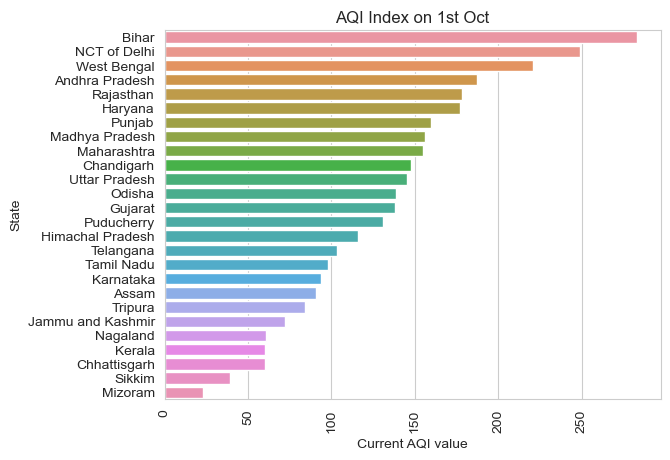

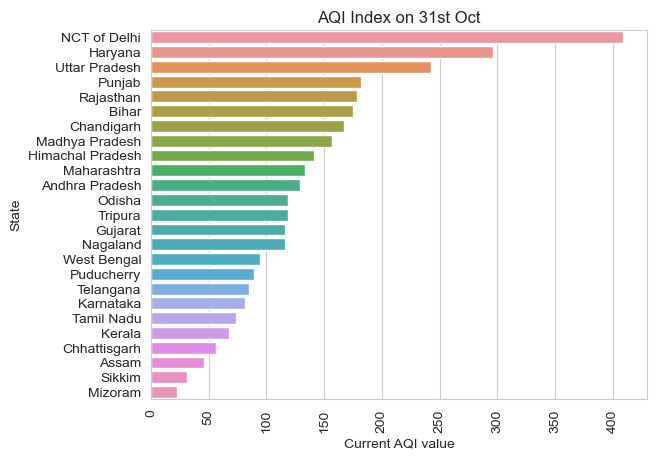

In [145]:
for num,i in enumerate([state_srt,state_end]):
    title = ["1st Oct","31st Oct"]
    ax = sns.barplot(data = i,y = "State",x = "Current AQI value")
    plt.title(f"AQI Index on {title[num]}")
    plt.xticks(rotation=90)
    plt.savefig(f"AQI Index on {title[num]}.jpg")
    plt.show()

#### States with minimum air quality problems

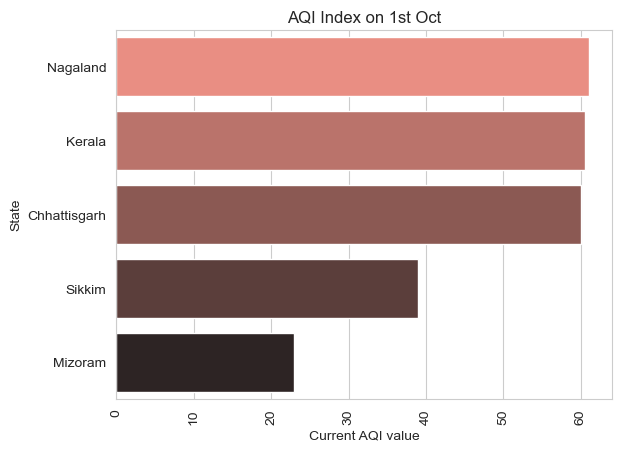

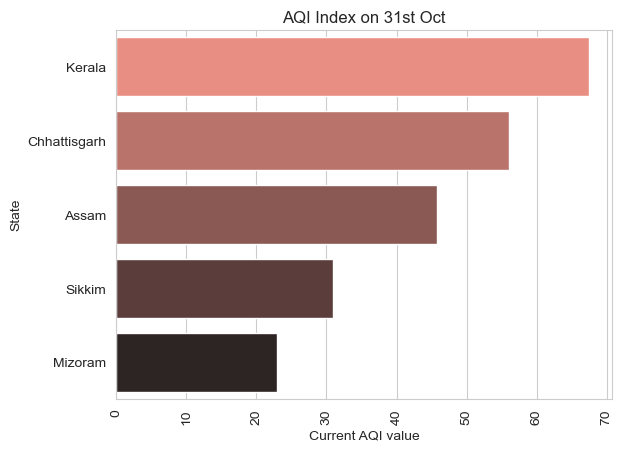

In [146]:
for num,i in enumerate([state_srt.iloc[-5:],state_end.iloc[-5:]]):
    title = ["1st Oct","31st Oct"]
    palette = ["dark:salmon_r","dark:salmon_r"]
    ax = sns.barplot(data = i,y = "State",x = "Current AQI value",palette = palette[num])
    plt.title(f"AQI Index on {title[num]}")
    plt.xticks(rotation=90)
    plt.savefig(f"AQI Index on {title[num]}.jpg")
    plt.show()

### Plotting the Air Quality Index on India's Map 

In [147]:
shp_gdf = gpd.read_file('Downloads/Indian_states.shp/Indian_states.shp')
shp_gdf.head()

,st_nm,geometry
0,Andaman & Nicobar Island,"MULTIPOLYGON (((93.71976 7.20707, 93.71909 7.2..."
1,Arunanchal Pradesh,"POLYGON ((96.16261 29.38078, 96.16860 29.37432..."
2,Assam,"MULTIPOLYGON (((89.74323 26.30362, 89.74290 26..."
3,Bihar,"MULTIPOLYGON (((84.50720 24.26323, 84.50355 24..."
4,Chandigarh,"POLYGON ((76.84147 30.75996, 76.83599 30.73623..."


In [148]:
merged_start = shp_gdf.set_index('st_nm').join(state_srt.set_index('State'))
merged_start['Current AQI value'].fillna(state_srt['Current AQI value'].mean(),inplace = True)

merged_end = shp_gdf.set_index('st_nm').join(state_end.set_index('State'))
merged_end['Current AQI value'].fillna(state_end['Current AQI value'].mean(),inplace = True)
merged_end.head()

,geometry,Current AQI value,Population,density
st_nm,,,,
Andaman & Nicobar Island,"MULTIPOLYGON (((93.71976 7.20707, 93.71909 7.2...",133.121388,NaN,NaN
Arunanchal Pradesh,"POLYGON ((96.16261 29.38078, 96.16860 29.37432...",133.121388,NaN,NaN
Assam,"MULTIPOLYGON (((89.74323 26.30362, 89.74290 26...",45.750000,31205576.0,398.0
Bihar,"MULTIPOLYGON (((84.50720 24.26323, 84.50355 24...",174.671053,104099452.0,1102.0
Chandigarh,"POLYGON ((76.84147 30.75996, 76.83599 30.73623...",167.000000,1055450.0,9252.0


<AxesSubplot:title={'center':'31st Oct AQI value in India state-wise'}>

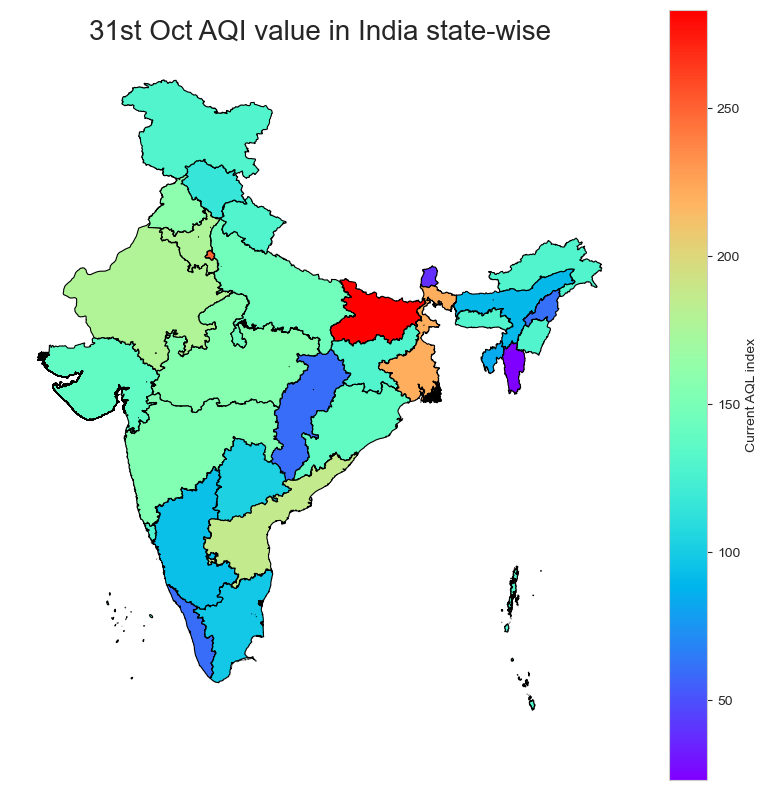

In [149]:
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.axis('off')
ax.set_title('31st Oct AQI value in India state-wise', fontdict={'fontsize': '20', 'fontweight' : '10'})
# Plot the figure
merged_start.plot(column='Current AQI value',cmap='rainbow', linewidth=0.8, ax=ax, edgecolor='0',legend=True,markersize=[39.739192, -104.990337], legend_kwds={'label': "Current AQL index"})

<AxesSubplot:title={'center':'31st Oct AQI value in India state-wise'}>

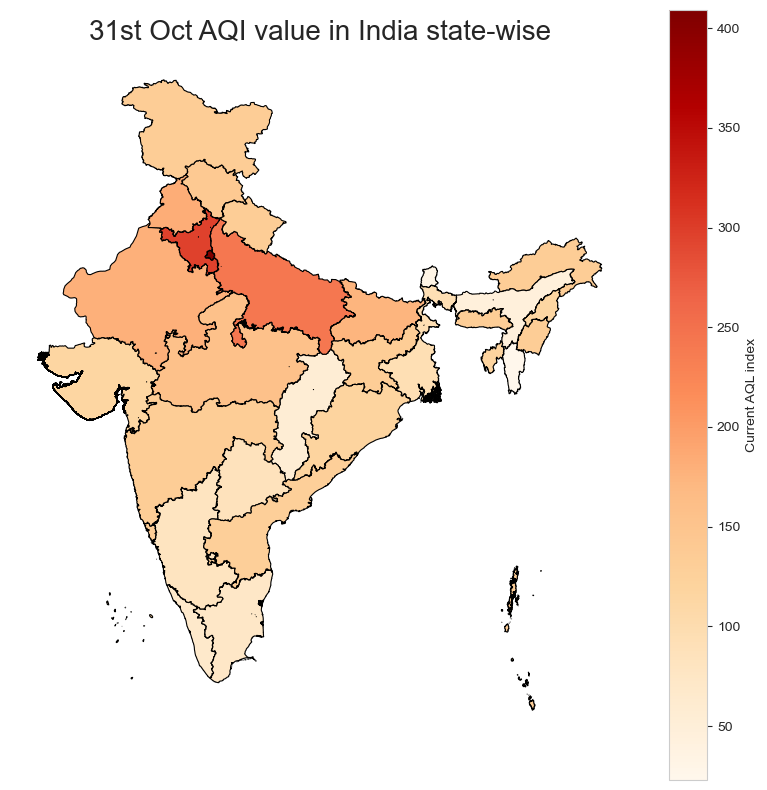

In [150]:
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.axis('off')
ax.set_title('31st Oct AQI value in India state-wise', fontdict={'fontsize': '20', 'fontweight' : '10'})
# Plot the figure
merged_end.plot(column='Current AQI value',cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0',legend=True,markersize=[39.739192, -104.990337], legend_kwds={'label': "Current AQL index"})

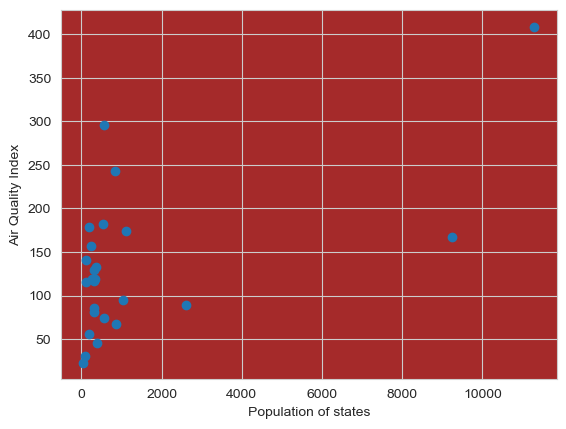

In [159]:
ax = plt.axes()

plt.scatter(x= state_end['density'],y = state_end['Current AQI value'])

plt.xlabel("Population of states")
plt.ylabel("Air Quality Index")

ax.set_facecolor("brown")
plt.show()

In [97]:
state_srt

,State,Current AQI value,Population
0,Bihar,283.125000,104099452.0
1,NCT of Delhi,248.867647,16787941.0
2,West Bengal,220.833333,91276115.0
3,Andhra Pradesh,187.000000,49577103.0
4,Rajasthan,178.250000,68548437.0
5,Haryana,177.250000,25351462.0
6,Punjab,159.875000,27743338.0
7,Madhya Pradesh,156.406250,72626809.0
8,Maharashtra,154.948529,112374333.0
9,Chandigarh,147.500000,1055450.0
